# Toy model of Grover Algorithm.


This notebook is a small educational Qiskit implementation of the **Subset Sum** mini-project. 

Given positive integers $x_0, x_1, \dots, x_{n-1}$ and a target integer $t$, the goal is to find a subset $I \subseteq \{0,\dots,n-1\}$ such that

$$\sum_{i\in I} x_i = t.$$

We encode a candidate subset using $n$ qubits:


$q_i = 0$  means do not choose $x_i$

$q_i = 1$  means choose $x_i$


For example, if the set is $\{2,4,6\}$, then we want to solve $2b_1 + 4b_2 + 6b_3 = s$ for an integer $s$. If we set $s = 2$. Then there is only one string $b_1 = 1, b_2 = 0, b_3 = 0$. This can be translated to a sebset $\{2\}$ via power set formulation. 

As one can see, Grover's Algorithm is perfect for this problem since it is just to find or search the right choices of bit strings. 

This notebook implements the simplest Grover-search version:

1. Classically identify the satisfying subsets for a small instance.
2. Build a phase oracle that marks exactly those satisfying bitstrings.
3. Apply the Grover diffuser.
4. Use `Statevector` simulation to inspect the resulting probabilities.

This is the easy version. It demonstrates the Grover mechanism clearly, but it is not yet the full reversible arithmetic oracle. In other jupyter notework, we will explore other more complex way of solving the subset sum problem. 

## 1. Basic of Grovers' Algorithm. 

This is a quick review of Grovers' algorithm. 

Step 1: Initial Seach of $N = 2^n$ items (via Hadamard Gate) 

 $$H^{\otimes n} \ket{0^n} = \frac{1}{\sqrt{N}} \sum_{x \in \{0, 1\}^n} \ket{x} = \ket{\varphi}$$

It simply means we initialize an uniform distribution over all possible states. 

Step 2: Search Operator Search and reflect the desired state $\ket{s}$, where the associated relfection operator is $$U_s = I - 2\ket{s}\bra{s}$$ 

Note this relfection is the Grover phase oracle: 

$$
U_s\ket{x}
=
\begin{cases}
-\ket{x}, & x=s,\\
\ket{x}, & x\neq s.
\end{cases}

$$

Step 3: Diffusion Operator Reflection about ht mean amplitude vecotr, where the associated relfection operator $$U_d = 2\ket{\varphi}\bra{\varphi} - I$$ 

Step 4: Repeat step 2 and step 3 in $O(\sqrt(n))$ time (This is due to a theorem)

-----------------------------
In our case, it is asking whether the subset is a solution. We will use an standard estimate $n = \left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{M}} \right\rfloor.$


## 1. Imports

In [21]:
from math import pi, sqrt, floor
from itertools import product

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

## 2. Classical subset-sum helper functions

We first write a classical checker. This makes the quantum encoding easier to debug.

Internally, we represent bitstrings in **qubit order**:


$$[q_0, q_1, ..., q_{n-1}]$$

But Qiskit displays bitstrings in the reverse order:

$$
q_{n-1}, ... q_1, q_0
$$

So we include explicit conversion functions.

It does three jobs:
1. Interpret bitstrings as subsets.
2. Find which bitstrings solve subset sum.
3. Convert between our bit order and Qiskit's displayed bitstrings.

In [22]:
def subset_sum_value(xs, bits_by_qubit):
    """
    Given xs = [x0, x1, ..., x_{n-1}]
    and bits_by_qubit = [q0, q1, ..., q_{n-1}],
    compute sum_i q_i * x_i.
    """
    return sum(x for x, bit in zip(xs, bits_by_qubit) if bit == 1)


def find_marked_subsets(xs, target):
    """
    Return all bitstrings [q0, q1, ..., q_{n-1}]
    such that sum_i q_i * x_i == target.
    """
    n = len(xs)
    marked = []

    for bits in product([0, 1], repeat=n):
        bits = list(bits)
        if subset_sum_value(xs, bits) == target:
            marked.append(bits)

    return marked


def bits_by_qubit_to_qiskit_bitstring(bits_by_qubit):
    """
    Qiskit displays bitstrings as q_{n-1} ... q1 q0.
    """
    return "".join(str(b) for b in reversed(bits_by_qubit))


def qiskit_bitstring_to_bits_by_qubit(bitstring):
    """
    Convert Qiskit's displayed bitstring back to qubit order.
    """
    return [int(b) for b in reversed(bitstring)]


def bits_to_subset(xs, bits_by_qubit):
    """
    Convert a bitstring to selected indices and values.
    """
    indices = [i for i, bit in enumerate(bits_by_qubit) if bit == 1]
    values = [xs[i] for i in indices]
    return indices, values

## 3. Choose a small demo instance

We use $x=[2,3,5]$ and $t=5$.

There are two valid subsets:

```text
2 + 3 = 5
5 = 5
```

So Grover should amplify two states.

In [13]:
xs = [2, 3, 5]
target = 5

marked_subsets = find_marked_subsets(xs, target)

print("Input xs:", xs)
print("Target:", target)
print()

print("Marked subsets:")
for bits in marked_subsets:
    indices, values = bits_to_subset(xs, bits)
    print(
        "bits by qubit =", bits,
        "| Qiskit display =", bits_by_qubit_to_qiskit_bitstring(bits),
        "| indices =", indices,
        "| values =", values,
        "| sum =", sum(values),
    )

Input xs: [2, 3, 5]
Target: 5

Marked subsets:
bits by qubit = [0, 0, 1] | Qiskit display = 100 | indices = [2] | values = [5] | sum = 5
bits by qubit = [1, 1, 0] | Qiskit display = 011 | indices = [0, 1] | values = [2, 3] | sum = 5


## 4. Phase oracle for one marked bitstring

Grover's oracle phase-flips good states:

$$|x\rangle \mapsto (-1)^{f(x)}|x\rangle.$$

Here $f(x)=1$ when the subset sum equals the target.

For the easy version, we phase-flip known satisfying bitstrings. To mark a target bitstring, we:

1. Apply `X` gates to convert the target pattern into $|11\cdots 1\rangle$.
2. Apply a controlled phase of $\pi$.
3. Undo the `X` gates.

This project allows controlled phase gates.

In [14]:
def add_phase_oracle_for_bitstring(qc, target_bits):
    """
    Phase flip exactly one computational-basis state.

    target_bits is in qubit order:
        [q0, q1, ..., q_{n-1}]
    """
    n = len(target_bits)

    # Convert the target bitstring to |11...1>.
    for i, bit in enumerate(target_bits):
        if bit == 0:
            qc.x(i)

    # Phase flip |11...1>.
    if n == 1:
        qc.p(pi, 0)
    else:
        qc.mcp(pi, list(range(n - 1)), n - 1)

    # Undo the conversion.
    for i, bit in enumerate(target_bits):
        if bit == 0:
            qc.x(i)


def add_subset_sum_oracle(qc, marked_subsets):
    """
    Phase flip all subsets satisfying the subset-sum equation.
    """
    for bits in marked_subsets:
        add_phase_oracle_for_bitstring(qc, bits)

## 5. Grover diffuser

The diffuser reflects amplitudes around their average. One Grover iteration is `oracle` then `diffuser`.

In [15]:
def add_grover_diffuser(qc, n):
    """
    Standard Grover diffuser on n qubits.
    """
    qc.h(range(n))
    qc.x(range(n))

    # Phase flip |11...1>.
    if n == 1:
        qc.p(pi, 0)
    else:
        qc.mcp(pi, list(range(n - 1)), n - 1)

    qc.x(range(n))
    qc.h(range(n))

## 6. Build the Grover circuit

The search space has size $N=2^n$.

If there are $M$ marked solutions, a standard estimate for the number of Grover iterations is:

$$\left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{M}} \right\rfloor.$$

For this example, $N=8$ and $M=2$, so one Grover iteration is enough.

Number of qubits: 3
Search space size N: 8
Number of marked states M: 2
Grover iterations: 1


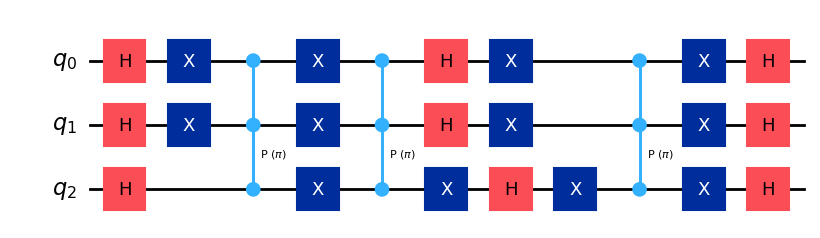

In [23]:
n = len(xs)
N = 2 ** n
M = len(marked_subsets)

if M == 0:
    num_iterations = 0
else:
    num_iterations = max(1, floor((pi / 4) * sqrt(N / M)))

print("Number of qubits:", n)
print("Search space size N:", N)
print("Number of marked states M:", M)
print("Grover iterations:", num_iterations)

qc = QuantumCircuit(n, name="subset_sum_grover")

# Start with the uniform superposition over all candidate subsets.
qc.h(range(n))

for _ in range(num_iterations):
    add_subset_sum_oracle(qc, marked_subsets)
    add_grover_diffuser(qc, n)

qc.draw("mpl", fold=-1)

## 7. Simulate with Statevector

We use `Statevector` instead of measurements because the assignment says no classical bits or measurements inside the circuit. Statevector simulation is just for benchmarking and inspection.

In [17]:
state = Statevector.from_instruction(qc)
probs = state.probabilities_dict()

top = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)

print("Top probabilities:")
for bitstring, prob in top:
    bits = qiskit_bitstring_to_bits_by_qubit(bitstring)
    indices, values = bits_to_subset(xs, bits)

    print(
        "Qiskit bitstring =", bitstring,
        "| bits by qubit =", bits,
        "| indices =", indices,
        "| values =", values,
        "| sum =", sum(values),
        "| probability =", round(prob, 6),
    )

Top probabilities:
Qiskit bitstring = 011 | bits by qubit = [1, 1, 0] | indices = [0, 1] | values = [2, 3] | sum = 5 | probability = 0.5
Qiskit bitstring = 100 | bits by qubit = [0, 0, 1] | indices = [2] | values = [5] | sum = 5 | probability = 0.5
Qiskit bitstring = 001 | bits by qubit = [1, 0, 0] | indices = [0] | values = [2] | sum = 2 | probability = 0.0
Qiskit bitstring = 010 | bits by qubit = [0, 1, 0] | indices = [1] | values = [3] | sum = 3 | probability = 0.0
Qiskit bitstring = 000 | bits by qubit = [0, 0, 0] | indices = [] | values = [] | sum = 0 | probability = 0.0
Qiskit bitstring = 111 | bits by qubit = [1, 1, 1] | indices = [0, 1, 2] | values = [2, 3, 5] | sum = 10 | probability = 0.0
Qiskit bitstring = 110 | bits by qubit = [0, 1, 1] | indices = [1, 2] | values = [3, 5] | sum = 8 | probability = 0.0
Qiskit bitstring = 101 | bits by qubit = [1, 0, 1] | indices = [0, 2] | values = [2, 5] | sum = 7 | probability = 0.0


## 8. Circuit benchmarking

In [18]:
print("Circuit depth:", qc.depth())
print("Gate counts:", qc.count_ops())
print("Number of qubits:", qc.num_qubits)

Circuit depth: 11
Gate counts: OrderedDict([('x', 12), ('h', 9), ('mcphase', 3)])
Number of qubits: 3


## 9. Larger required-scale example: $n=4$

The bootcamp requirement for this project only needs small instances, for example $n \leq 4$ and $x_i < 8$.

Here is a reusable reporting function.

In [ ]:
def build_grover_subset_sum_circuit(xs, target):
    n = len(xs)
    marked_subsets = find_marked_subsets(xs, target)

    N = 2 ** n
    M = len(marked_subsets)

    qc = QuantumCircuit(n, name="subset_sum_grover")
    qc.h(range(n))

    if M == 0:
        return qc, marked_subsets, 0

    num_iterations = max(1, floor((pi / 4) * sqrt(N / M)))

    for _ in range(num_iterations):
        add_subset_sum_oracle(qc, marked_subsets)
        add_grover_diffuser(qc, n)

    return qc, marked_subsets, num_iterations


def simulate_and_report(xs, target, top_k=8):
    qc, marked_subsets, num_iterations = build_grover_subset_sum_circuit(xs, target)

    state = Statevector.from_instruction(qc)
    probs = state.probabilities_dict()
    top = sorted(probs.items(), key=lambda kv: kv[1], reverse=True)[:top_k]

    print("=" * 72)
    print("Subset Sum with Grover")
    print("=" * 72)
    print("xs:", xs)
    print("target:", target)
    print("selection qubits:", len(xs))
    print("search space size:", 2 ** len(xs))
    print("marked states:", len(marked_subsets))
    print("Grover iterations:", num_iterations)
    print()

    print("Marked subsets:")
    if not marked_subsets:
        print("  No exact solution.")
    else:
        for bits in marked_subsets:
            indices, values = bits_to_subset(xs, bits)
            print(
                "  bits =", bits,
                "| Qiskit display =", bits_by_qubit_to_qiskit_bitstring(bits),
                "| indices =", indices,
                "| values =", values,
                "| sum =", sum(values),
            )

    print()
    print("Top probabilities:")
    for bitstring, prob in top:
        bits = qiskit_bitstring_to_bits_by_qubit(bitstring)
        indices, values = bits_to_subset(xs, bits)
        print(
            "  bitstring =", bitstring,
            "| bits =", bits,
            "| values =", values,
            "| sum =", sum(values),
            "| prob =", round(prob, 6),
        )

    print()
    print("Circuit depth:", qc.depth())
    print("Gate counts:", qc.count_ops())
    print("Number of qubits:", qc.num_qubits)

    return qc, probs, marked_subsets

In [ ]:
# Example with n = 4 and xi < 8
qc4, probs4, marked4 = simulate_and_report([2, 3, 5, 7], 10)

Subset Sum with Grover
xs: [2, 3, 5, 7]
target: 10
selection qubits: 4
search space size: 16
marked states: 2
Grover iterations: 2

Marked subsets:
  bits = [0, 1, 0, 1] | Qiskit display = 1010 | indices = [1, 3] | values = [3, 7] | sum = 10
  bits = [1, 1, 1, 0] | Qiskit display = 0111 | indices = [0, 1, 2] | values = [2, 3, 5] | sum = 10

Top probabilities:
  bitstring = 0111 | bits = [1, 1, 1, 0] | values = [2, 3, 5] | sum = 10 | prob = 0.472656
  bitstring = 1010 | bits = [0, 1, 0, 1] | values = [3, 7] | sum = 10 | prob = 0.472656
  bitstring = 1011 | bits = [1, 1, 0, 1] | values = [2, 3, 7] | sum = 12 | prob = 0.003906
  bitstring = 1110 | bits = [0, 1, 1, 1] | values = [3, 5, 7] | sum = 15 | prob = 0.003906
  bitstring = 1111 | bits = [1, 1, 1, 1] | values = [2, 3, 5, 7] | sum = 17 | prob = 0.003906
  bitstring = 0100 | bits = [0, 0, 1, 0] | values = [5] | sum = 5 | prob = 0.003906
  bitstring = 1100 | bits = [0, 0, 1, 1] | values = [5, 7] | sum = 12 | prob = 0.003906
  bitstring

Note this is not a real subset sum solver. It is just amplifying the classical solver. 

The “real” approach is:

input subset bits b0,...,b_{n-1}
compute weighted sum S = b0*x0 + ... + b_{n-1}*x_{n-1}
phase-flip if S == target
uncompute S
apply diffuser